In [1]:
import os
import numpy as np
import pandas as pd
import re
import argparse
import pickle

import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential , load_model
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense , Input, Dropout   
from tensorflow.keras.callbacks import EarlyStopping ,ModelCheckpoint, ReduceLROnPlateau

from sklearn.metrics import classification_report, confusion_matrix

 

2026-05-17 09:13:55.517466: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779009235.768633      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779009235.843977      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779009236.425177      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779009236.425218      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779009236.425221      57 computation_placer.cc:177] computation placer alr

In [2]:
# ─────────────────────────────────────────────
# Configuration
# ─────────────────────────────────────────────
class Config:
    CSV_PATH        = "/kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv"
    REVIEW_COL      = "review"
    SENTIMENT_COL   = "sentiment"
    EMBEDDING_DIM   = 128
    LSTM_UNITS      = 128
    DROPOUT         = 0.3
    BATCH_SIZE      = 64
    EPOCHS          = 15
    LEARNING_RATE   = 1e-3
    TEST_SIZE       = 0.2
    VOCAB_SIZE = 20_000
    RANDOM_STATE    = 42
    MODEL_DIR       = "LSTM_model"
    MODEL_PATH      = "LSTM_model/lstm_imdb.keras"
    TOKENIZER_PATH  = "LSTM_model/tokenizer.pkl"
    HISTORY_PLOT    = "LSTM_model/training_history.png"
    CONFUSION_PLOT  = "LSTM_model/confusion_matrix.png"


In [3]:
# ─────────────────────────────────────────────
# Data Loading
# ─────────────────────────────────────────────
    
def load_data(csv_path :str, review_col: str, sentiment_col: str):
    print(f"\n{'=' * 55}")
    print(f" Loading dataset: {csv_path}")
    print(f"{'=' * 55}")
    
    df = None
    """Load stock data from a CSV file or fall back to built-in sample data."""
    if csv_path and os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
        # check if df has the required columns
        
        if review_col not in df.columns or sentiment_col not in df.columns:
            print(f"  ⚠️ CSV file is missing required columns:")
            print(f"Expected columns '{review_col}' and '{sentiment_col}'.\n")
            print(f"Found: {list(df.columns)}")
            return None
        
        print(f"  ✓ Loaded {len(df)} rows from {csv_path}")
        
    else:
        print("  ⚠️ CSV file not found.")
        
   
    return df

In [4]:
# ─────────────────────────────────────────────
# Text Preprocessing
# ─────────────────────────────────────────────
def preprocess_data(df, review_col, sentiment_col):
    """Preprocess text data: clean, tokenize, and encode."""
    print("  Preprocessing text data...")
    df = df.dropna(subset=[review_col, sentiment_col])
    
    print("  Cleaning text...")
    df[review_col] = df[review_col].apply(clean_text)
    
    # Encode labels
    label_encoder = LabelEncoder()
    df[sentiment_col] = label_encoder.fit_transform(df[sentiment_col])
    print(f"  ✓  Data preprocessing complete. ")
    print(f"  ✓  Data encoding complete. ")
    
    # Tokenize
    print(f"  Tokenizing ...")
    
    tokenizer = Tokenizer()
    tokenizer.fit_on_texts(df[review_col])
    
    sequences = tokenizer.texts_to_sequences(df[review_col])
    max_len = max(len(seq) for seq in sequences)
    X = pad_sequences(sequences, maxlen=max_len )
    y = df[sentiment_col].values
    
    return df, label_encoder, tokenizer, sequences , X, y, max_len

def clean_text(text: str) -> str:
    
    """Strip HTML, URLs, non-alpha chars, and normalize."""
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"http\S+", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text.lower()


In [5]:


# ─────────────────────────────────────────────
# Model Architecture
# ─────────────────────────────────────────────
def build_model(tokenizer, max_len) -> Sequential:
    """
    Embedding -> LSTM(128) -> Dropout -> Dense(64) -> Dense(1, sigmoid)
    """
    
    #vocab_size = len(tokenizer.word_index) + 1  # This should match the tokenizer's vocab size
    

    model = Sequential([
        Input(shape=(max_len,), name="input"),
        Embedding(
            input_dim=Config.VOCAB_SIZE,
            output_dim=Config.EMBEDDING_DIM,
            name="embedding",
        ),
        LSTM(Config.LSTM_UNITS, name="lstm"),
        Dropout(Config.DROPOUT, name="dropout_1"),
        Dense(64, activation="relu", name="dense_hidden"),
        Dropout(0.2, name="dropout_2"),
        Dense(1, activation="sigmoid", name="output"),
    ])
 
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=Config.LEARNING_RATE),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    
    return model

In [6]:
# ─────────────────────────────────────────────
# Training
# ─────────────────────────────────────────────

def train_model(x_train, y_train, x_test, y_test, tokenizer, max_len):
    os.makedirs(Config.MODEL_DIR, exist_ok=True)
 
    model = build_model(tokenizer, max_len)
    model.summary()
    
    callbacks = [
        EarlyStopping(
            monitor="val_loss", patience=3,
            restore_best_weights=True, verbose=1,
        ),
        ModelCheckpoint(
            Config.MODEL_PATH, monitor="val_accuracy",
            save_best_only=True, verbose=1,
        ),
        ReduceLROnPlateau(
            monitor="val_loss", factor=0.5,
            patience=2, min_lr=1e-6, verbose=1,
        ),
    ]

    print(f"\n{'=' * 55}")
    print(" Training LSTM model...")
    print(f"{'=' * 55}\n")

    history = model.fit(
        x_train, y_train,
        validation_data=(x_test, y_test),
        epochs=Config.EPOCHS,
        batch_size=Config.BATCH_SIZE,
        callbacks=callbacks,
        verbose=1,
    )

    return model, history
 

In [7]:

# ─────────────────────────────────────────────
# Evaluation
# ─────────────────────────────────────────────
def evaluate(model, x_test, y_test):
    print(f"\n{'=' * 55}")
    print(" Evaluating on test set...")
    print(f"{'=' * 55}\n")
 
    loss, accuracy = model.evaluate(x_test, y_test, verbose=0)
    print(f"  Test Loss:     {loss:.4f}")
    print(f"  Test Accuracy: {accuracy:.4f}")
 
    y_pred = (model.predict(x_test, verbose=0) > 0.5).astype(int).flatten()
 
    print(f"\n{'=' * 55}")
    print(" Classification Report")
    print(f"{'=' * 55}")
    print(classification_report(y_test, y_pred, target_names=["Negative", "Positive"]))
 
    return y_pred
 

In [8]:

# ─────────────────────────────────────────────
# Plots
# ─────────────────────────────────────────────
def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
 
    ax1.plot(history.history["accuracy"],     label="Train",      linewidth=2, color="#00b894")
    ax1.plot(history.history["val_accuracy"],  label="Validation", linewidth=2, color="#0984e3")
    ax1.set_title("Model Accuracy", fontsize=14, fontweight="bold")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Accuracy")
    ax1.legend()
    ax1.grid(alpha=0.3)
 
    ax2.plot(history.history["loss"],     label="Train",      linewidth=2, color="#00b894")
    ax2.plot(history.history["val_loss"],  label="Validation", linewidth=2, color="#0984e3")
    ax2.set_title("Model Loss", fontsize=14, fontweight="bold")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Loss")
    ax2.legend()
    ax2.grid(alpha=0.3)
 
    plt.tight_layout()
    plt.savefig(Config.HISTORY_PLOT, dpi=150, bbox_inches="tight")
    print(f"\n  Training curves saved -> {Config.HISTORY_PLOT}")
 
 
def plot_confusion_matrix(y_test, y_pred):
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
    fig.colorbar(im)
    ax.set(
        xticks=[0, 1], yticks=[0, 1],
        xticklabels=["Negative", "Positive"],
        yticklabels=["Negative", "Positive"],
        xlabel="Predicted", ylabel="Actual",
        title="Confusion Matrix",
    )
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i, j]:,}",
                    ha="center", va="center", fontsize=16, fontweight="bold",
                    color="white" if cm[i, j] > cm.max() / 2 else "black")
    plt.tight_layout()
    plt.savefig(Config.CONFUSION_PLOT, dpi=150, bbox_inches="tight")
    print(f"  Confusion matrix saved -> {Config.CONFUSION_PLOT}")
 


 Loading dataset: /kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv
  ✓ Loaded 50000 rows from /kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv
  Preprocessing text data...
  Cleaning text...
  ✓  Data preprocessing complete. 
  ✓  Data encoding complete. 
  Tokenizing ...


I0000 00:00:1779009283.513512      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779009283.519380      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 2494, 128)      │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,699,905 (10.30 MB)

 Trainable params: 2,699,905 (10.30 MB)

 Non-trainable params: 0 (0.00 B)


 Training LSTM model...

Epoch 1/15


I0000 00:00:1779009288.400177     129 cuda_dnn.cc:529] Loaded cuDNN version 91002


625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.7325 - loss: 0.5200
Epoch 1: val_accuracy improved from -inf to 0.87590, saving model to LSTM_model/lstm_imdb.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 73s 109ms/step - accuracy: 0.7327 - loss: 0.5199 - val_accuracy: 0.8759 - val_loss: 0.3084 - learning_rate: 0.0010
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.9111 - loss: 0.2362
Epoch 2: val_accuracy did not improve from 0.87590
625/625 ━━━━━━━━━━━━━━━━━━━━ 70s 112ms/step - accuracy: 0.9111 - loss: 0.2362 - val_accuracy: 0.8688 - val_loss: 0.3077 - learning_rate: 0.0010
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.9427 - loss: 0.1621
Epoch 3: val_accuracy improved from 0.87590 to 0.88990, saving model to LSTM_model/lstm_imdb.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 70s 112ms/step - accuracy: 0.9427 - loss: 0.1621 - val_accuracy: 0.8899 - val_loss: 0.2857 - learning_rate: 0.0010
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.96

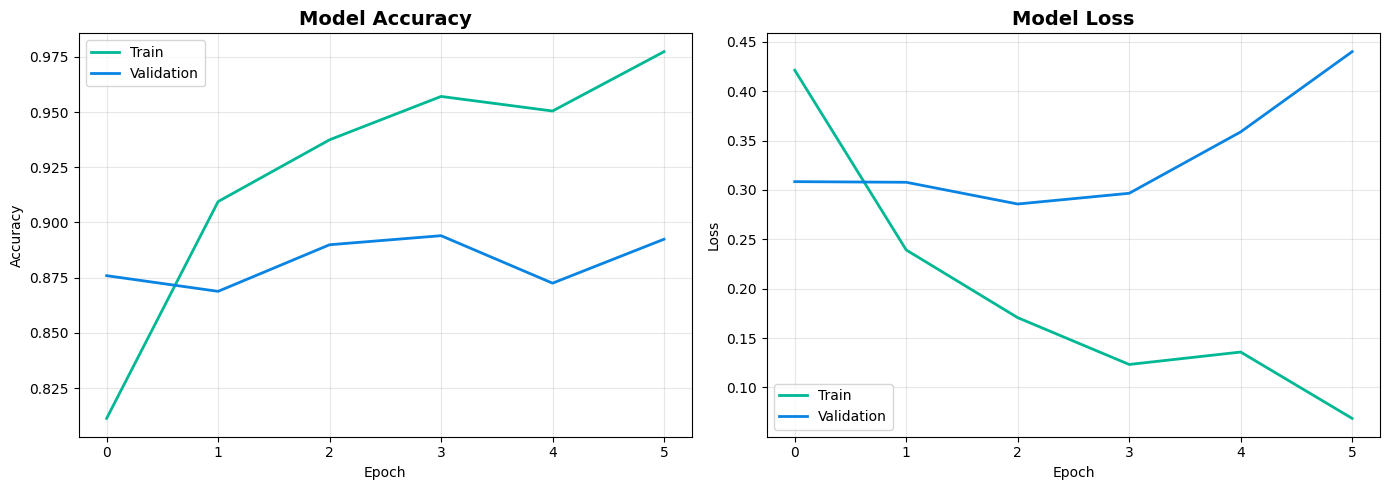

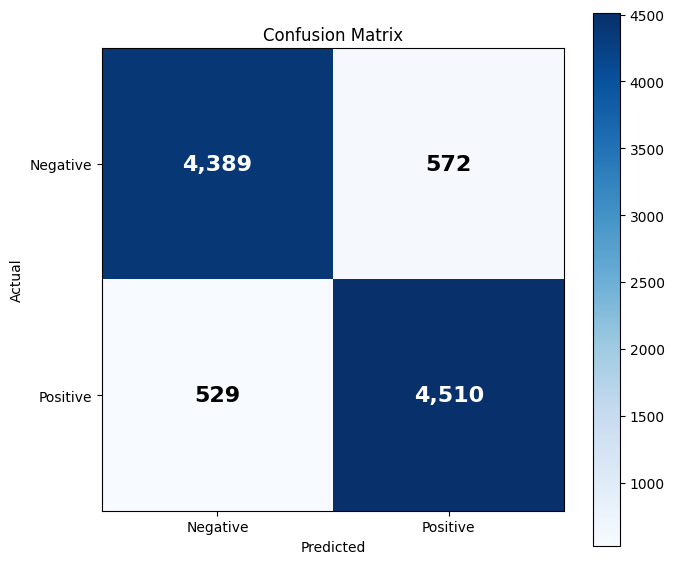

In [9]:

# ─────────────────────────────────────────────
# Main
# ─────────────────────────────────────────────
def main():
     
    # ── Load data ──
    df= load_data(
        # args.csv, args.review_col, args.sentiment_col
        Config.CSV_PATH, Config.REVIEW_COL, Config.SENTIMENT_COL
    )
    
     # ── Preprocess data ──
    df, label_encoder, tokenizer, sequences , X, y, max_len = preprocess_data(df , Config.REVIEW_COL, Config.SENTIMENT_COL)
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

 
    model , history = train_model(X_train, y_train, X_test, y_test, tokenizer, max_len)
 
    # Save tokenizer
    os.makedirs(Config.MODEL_DIR, exist_ok=True)
    with open(Config.TOKENIZER_PATH, "wb") as f:
        pickle.dump({"tokenizer": tokenizer, "max_len": max_len}, f)
    print(f"  Tokenizer saved -> {Config.TOKENIZER_PATH}")
    

    # Evaluate
    y_pred = evaluate(model, X_test, y_test)

    # Plots
    plot_training_history(history)
    plot_confusion_matrix(y_test, y_pred)
 


 
if __name__ == "__main__":
    main()
 

In [10]:

# ─────────────────────────────────────────────
# Single-review Prediction
# ─────────────────────────────────────────────
def predict_review(text: str ):
    
    print(f"  Loading model from {Config.MODEL_PATH}")
    model = load_model(Config.MODEL_PATH)
     
    print(f"  Loading tokenizer from {Config.TOKENIZER_PATH}")
    with open(Config.TOKENIZER_PATH, "rb") as f:
        data = pickle.load(f)
        tokenizer = data["tokenizer"]
        max_len = data["max_len"]
 
    cleaned = clean_text(text)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=max_len )
 
    score = model.predict(padded, verbose=0)[0][0]
    label = "POSITIVE" if score >= 0.5 else "NEGATIVE"
    confidence = abs(score - 0.5) * 2
 
    print(f"\n  Review:     {text[:100]}{'...' if len(text) > 100 else ''}")
    print(f"  Sentiment:  {label}")
    print(f"  Score:      {score:.4f}")
    print(f"  Confidence: {confidence:.1%}")
 
    return label, score, confidence
 

In [11]:

# Demo predictions
demo = [
    "This movie was absolutely brilliant, a true masterpiece of cinema!",
    "Terrible film. Boring, poorly acted, and a complete waste of time.",
    "It was okay, nothing special but not terrible either.",
]
print(f"\n{'=' * 55}")
print(" Demo Predictions")
print(f"{'=' * 55}")

for review in demo:
    predict_review(review )

print(f"\n{'=' * 55}")
print(f" Done! Artifacts saved to ./{Config.MODEL_DIR}/")
print(f"{'=' * 55}")
print(f"  Model:            {Config.MODEL_PATH}")
print(f"  Tokenizer:        {Config.TOKENIZER_PATH}")
print(f"  Training curves:  {Config.HISTORY_PLOT}")
print(f"  Confusion matrix: {Config.CONFUSION_PLOT}")


 Demo Predictions
  Loading model from LSTM_model/lstm_imdb.keras
  Loading tokenizer from LSTM_model/tokenizer.pkl

  Review:     This movie was absolutely brilliant, a true masterpiece of cinema!
  Sentiment:  POSITIVE
  Score:      0.9249
  Confidence: 85.0%
  Loading model from LSTM_model/lstm_imdb.keras
  Loading tokenizer from LSTM_model/tokenizer.pkl

  Review:     Terrible film. Boring, poorly acted, and a complete waste of time.
  Sentiment:  NEGATIVE
  Score:      0.0008
  Confidence: 99.8%
  Loading model from LSTM_model/lstm_imdb.keras
  Loading tokenizer from LSTM_model/tokenizer.pkl

  Review:     It was okay, nothing special but not terrible either.
  Sentiment:  NEGATIVE
  Score:      0.0424
  Confidence: 91.5%

 Done! Artifacts saved to ./LSTM_model/
  Model:            LSTM_model/lstm_imdb.keras
  Tokenizer:        LSTM_model/tokenizer.pkl
  Training curves:  LSTM_model/training_history.png
  Confusion matrix: LSTM_model/confusion_matrix.png
